# Global CO₂ Emissions: Exploratory Data Analysis (1970–2024)

**Objective:** Analyze historical total and per-capita CO₂ emissions across
countries to understand global emission trends, identify top emitters,
detect anomalies, and produce a clean, feature-engineered dataset for the
Global Climate & Sustainability Dashboard project.

**Data source:** World Bank Indicators API
- `EN.GHG.CO2.MT.CE.AR5` — Total CO₂ emissions, excluding LULUCF (Mt CO₂e)
- `EN.GHG.CO2.PC.CE.AR5` — CO₂ emissions per capita, excluding LULUCF (t CO₂e/person)

**Coverage:** 1970–2024, country and regional aggregate level

**This notebook covers:** data cleaning (zero-value forensics, duplicate
removal, aggregate/country separation), feature engineering (rolling
averages, YoY change, log-transform, statistical outlier and temporal
anomaly detection), and exploratory visualization to answer the six
research questions below.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import seaborn as sns

import pycountry

In [3]:
import sys
import os

# Add project root (two levels up from notebooks/eda)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

from src.api.CO2_emission import co2_emission

#### Indicator Code           | Description                            | Unit |

- EN.GHG.CO2.MT.CE.AR5`` | Total CO₂ emissions (excluding LULUCF) | Mt CO₂e |
- EN.GHG.CO2.PC.CE.AR5`` | CO₂ emissions per capita (excluding LULUCF) | t CO₂e per person |

#### Fetching data 

In [4]:
raw_df , metadata = co2_emission( )
value = 'T_CO₂_emi(in mt)'
raw_df.head() 
 

,date,T_CO₂_emi(in mt),Country_code,Co2_per_capita(in ton)
0,2025,NaN,AFE,NaN
1,2024,634.4063,AFE,0.837680
2,2023,619.3657,AFE,0.838104
3,2022,618.5414,AFE,0.858132
4,2021,631.4195,AFE,0.899170


In [5]:
def code_to_name(iso3):
    try:
        return pycountry.countries.get(alpha_3=iso3).name
    except AttributeError:
        return None  # code not found (could be an aggregate like WLD)

raw_df['Country_name'] = raw_df['Country_code'].apply(code_to_name)

#### Saving raw data 

In [6]:
# saving raw data
raw_df.to_csv('../../data/raw/co2_emission.csv' , index =False)

In [7]:
metadata 


{'id': 'EN.GHG.CO2.MT.CE.AR5',
 'name': 'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
 'unit': '',
 'source': {'id': '2', 'value': 'World Development Indicators'},
 'sourceNote': "A measure of annual emissions of carbon dioxide (CO2), one of the six Kyoto greenhouse gases (GHG), from the agriculture, energy, waste, and industrial sectors, excluding LULUCF. The measure is standardized to carbon dioxide equivalent values using the Global Warming Potential (GWP) factors of IPCC's 5th Assessment Report (AR5).",
 'sourceOrganization': 'EDGAR (Emissions Database for Global Atmospheric Research) Community GHG Database, Joint Research Centre (JRC) - European Commission, uri: https://edgar.jrc.ec.europa.eu/dataset_ghg2024, publisher: JRC European Commission, date published: 2024;\nInternational Energy Agency (IEA), uri: https://edgar.jrc.ec.europa.eu/dataset_ghg2024, publisher: International Energy Agency (IEA), date published: 2024',
 'topics': [{'id': '6', 'value': 'Env

In [8]:
data = pd.read_csv('../../data/raw/co2_emission.csv' )

data.sample(10)

,date,T_CO₂_emi(in mt),Country_code,Co2_per_capita(in ton),Country_name
1424,1987,9361.7938,IBT,2.302452,NaN
18734,1969,NaN,ZMB,NaN,Zambia
17288,1963,NaN,TLS,NaN,Timor-Leste
17973,2004,115.0197,ARE,25.969871,United Arab Emirates
6894,1995,0.1336,CYM,4.080261,Cayman Islands
15385,2018,0.1525,STP,0.725544,Sao Tome and Principe
4623,2022,189.1886,DZA,4.160059,Algeria
3477,1980,53.8576,OSS,7.861707,NaN
16585,2006,NaN,MAF,NaN,Saint Martin (French part)
1112,2001,15260.2640,NaN,0.938549,NaN


## Data Cleaning 


In [9]:
print(data.info())

df_columns = data.columns.to_list()
print('dataset columns are :',df_columns)

<class 'pandas.DataFrame'>
RangeIndex: 18810 entries, 0 to 18809
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    18810 non-null  int64  
 1   T_CO₂_emi(in mt)        14630 non-null  float64
 2   Country_code            17160 non-null  str    
 3   Co2_per_capita(in ton)  14630 non-null  float64
 4   Country_name            14190 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 734.9 KB
None
dataset columns are : ['date', 'T_CO₂_emi(in mt)', 'Country_code', 'Co2_per_capita(in ton)', 'Country_name']


In [10]:
data.describe()

,date,T_CO₂_emi(in mt),Co2_per_capita(in ton)
count,18810.000000,14630.000000,14630.000000
mean,1992.500000,1226.556051,4.796195
std,19.050878,3679.259681,10.134250
min,1960.000000,0.000000,0.000000
25%,1976.000000,1.676550,0.513606
50%,1992.500000,22.951350,2.046275
75%,2009.000000,275.751375,6.171439
max,2025.000000,39632.664219,202.865184


#### Handling 0 values in dataset


In [11]:
# checking for 0 values 
zero_val = data[data[value]== 0][value].count()
print(f'total Zero values are {zero_val}')

# investigating zero rows
zero_rows = data[data[value] == 0]
# zero_df = zero_rows.groupby( 'Country_name', )['date'].count().to_frame()
min_dates = zero_rows.groupby("Country_name")['date'].min().reset_index(name='min_date')
max_dates = zero_rows.groupby("Country_name")['date'].max().reset_index(name='max_date')
date_df =   min_dates.merge(max_dates)

print('list of countries that has 0 values , with min and max Years : ') 
print(date_df)


total Zero values are 150
list of countries that has 0 values , with min and max Years : 
               Country_name  min_date  max_date
0            American Samoa      1970      1980
1          Marshall Islands      1970      1981
2                     Nauru      1970      2024
3  Northern Mariana Islands      1970      1986
4                    Tuvalu      1970      2024


So there are only 5 countries that have 0 as co2 values . here are the explanation for each countries 0 data .


#### 0 values explanation
- For 'American Samoa' and 'Marshall Islands', continuous 10 & 11 year null data show there could be a genuine reason for not recording data instead of false/wrong values and that why this could be count as null data.
- For 'Nauru' and 'Tuvalu' both have null value for whole dataSet that show no actual data record for these 2 countries . so it can be dropped 



In [12]:
# for [American Samoa ,Marshall Islands ,Nauru, Tuvalu  ] coverting those 0 as NaN ,
# so it can be removed latter
nan_country = ["American Samoa" ,"Marshall Islands" ,"Nauru", 'Tuvalu'  ]

# keep full dataset, but only change CO₂ values for those countries
data.loc[data['Country_name'].isin(nan_country) , value] = (data.loc[data['Country_name'].isin(nan_country) , value].
                                                        replace(0 , np.nan))


 

for Northern Mariana Islands it shows there is very small values over years . that why 0 could be the actual co2 Values so will keep them 


In [13]:
# checking for missing values
missing_values = data.isna().sum().sum()
print(f'total NaN values is {missing_values}')

# checking for duplicate values 
duplicates = data.duplicated().sum()
print('total duplicate data is :' , duplicates)


total NaN values is 14763
total duplicate data is : 264


In [14]:
# droping duplicates data
before = len(data)
data = data.drop_duplicates()
after = len(data)
print(f"Dropped {before-after} exact duplicate rows")

# droping missing values  
data = data.dropna(subset = [value , 'Country_code'])
print(f'Total NaN values after droping is : {data.isna().sum().sum()}')
 


Dropped 264 exact duplicate rows
Total NaN values after droping is : 2365


In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 13397 entries, 1 to 18799
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    13397 non-null  int64  
 1   T_CO₂_emi(in mt)        13397 non-null  float64
 2   Country_code            13397 non-null  str    
 3   Co2_per_capita(in ton)  13397 non-null  float64
 4   Country_name            11032 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 628.0 KB


### Creating a list of Aggregated countries code

Since this dataset contains country and aggregate country so we will create 2 DataFrame 1 for only country (to visualize for country trend) 
and 1 for dataFrame with aggregate country ( to show regional data)


In [16]:
mask_missing =  (data['Country_name'].isna() 
                 |(data['Country_name'].astype(str).str.strip() == "")
                 |(data['Country_name'].astype(str).str.lower() == "nan"))
agg_country_df = data[mask_missing].copy()
agg_code = data.loc[mask_missing, 'Country_code'].dropna().unique().tolist() # list of agg country
print(agg_country_df.shape)
print('total aggregated countries :',len(agg_code))


(2365, 5)
total aggregated countries : 43


- Creating a data Frame with aggregate country : 'agg_df' 
- And a DataFrame with no aggregate Country : 'df'

In [17]:
 
agg_df = data.copy()            # dataframe with aggregated+all country
print('For dataframe with aggregated country')
print('total null values is ', agg_df.isnull().sum().sum())
print('DataFrame shape is :' , agg_df.shape)
print('  \n ')

df = data[~data['Country_code'].isin(agg_code)].copy() #dataFramw with only country (no aggregate country)
print('For dataFramw with no aggregate country ')
print('total null values is ', df.isnull().sum().sum())
print('DataFrame shape is :' , df.shape) 

For dataframe with aggregated country
total null values is  2365
DataFrame shape is : (13397, 5)
  
 
For dataFramw with no aggregate country 
total null values is  0
DataFrame shape is : (11032, 5)


agg_df is created separately for regional/aggregate views in the dashboard, not used in this country-level EDA" — and an actual export cell:


In [18]:
df.groupby('Country_code')
df

,date,T_CO₂_emi(in mt),Country_code,Co2_per_capita(in ton),Country_name
4489,2024,12.0684,AFG,0.282980,Afghanistan
4490,2023,11.6486,AFG,0.280995,Afghanistan
4491,2022,11.2980,AFG,0.278421,Afghanistan
4492,2021,12.4864,AFG,0.312157,Afghanistan
4493,2020,12.1436,AFG,0.310825,Afghanistan
...,...,...,...,...,...
18795,1974,10.4036,ZWE,1.760837,Zimbabwe
18796,1973,10.5544,ZWE,1.845045,Zimbabwe
18797,1972,9.0937,ZWE,1.640738,Zimbabwe
18798,1971,9.4795,ZWE,1.763722,Zimbabwe


# Feature engineering

In [19]:
df = df.sort_values( ['Country_code' , 'date' ])

# calculating rolling mean
df['3y_rolling_mean'] = df.groupby('Country_code')[value].transform(lambda x: x.rolling(3 , min_periods = 3).mean())

Flagging CO2 as per its values to identify high emitting or anomaly .

In [20]:
# High emitter by percentile (99th)
threshold_high = df[value].quantile(0.99)
df['is_high_emitter'] = df[value] > threshold_high
df.head()

# temporal anomaly: large year-over-year jump
df = df.sort_values(['Country_code' , 'date'])
df['co2_yoy_pct'] = df.groupby('Country_code')[value].pct_change()* 100
df['yoy_std_5yr'] = df.groupby('Country_code')['co2_yoy_pct'].transform(lambda x: x.rolling(5, min_periods=1).std().abs())
df['is_temporal_anomaly'] = (df['co2_yoy_pct'].abs() > 3 * df['yoy_std_5yr']) & (df['co2_yoy_pct'].abs() > 50)

 

Visualizing the distribution of co2 emission values 


Text(0.5, 1.0, 'boxplot for "T_CO₂_emi(in mt)" (outlier show as points)')

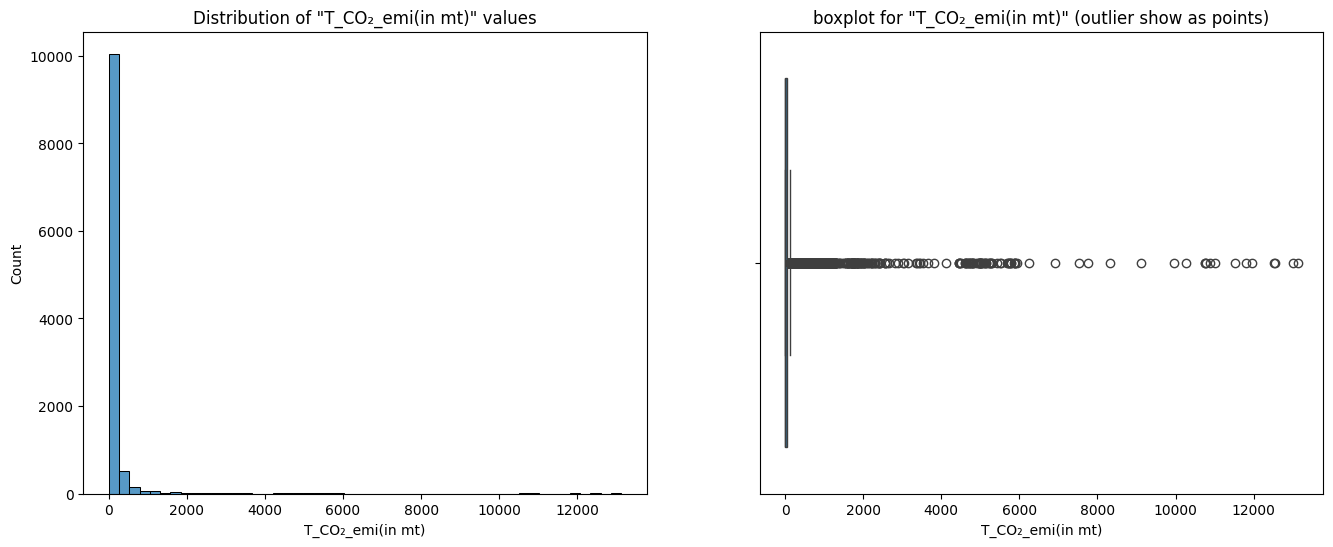

In [21]:
# cheching data distribution of co2

plt.figure(figsize = (16,6))

plt.subplot(1,2,1)
sns.histplot(df[value] , bins = 50)
plt.title(f'Distribution of "{value}" values')

plt.subplot(1,2,2)
sns.boxplot(x= df[value])
plt.title(f'boxplot for "{value}" (outlier show as points)')


since co2 is heavily right-skew , performing log-transform on co2 data to fit statistical methods

Text(0.5, 1.0, 'boxplot for co2 (outlier show as points) (after log_transformation)')

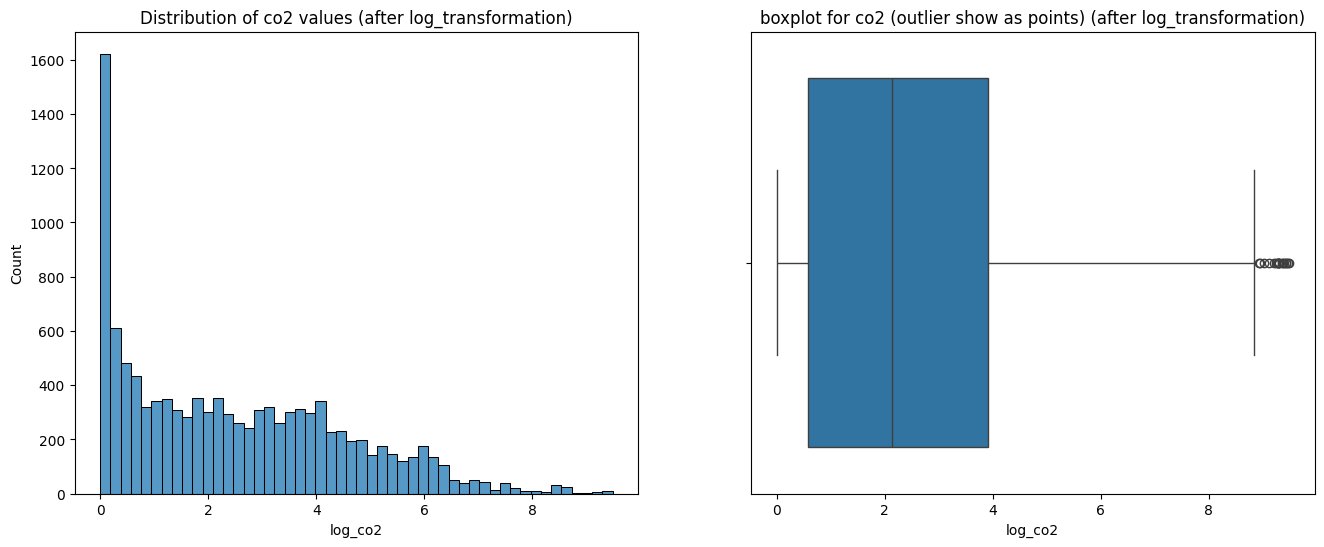

In [22]:
df['log_co2'] =np.log1p(df[value])

# ploting log-transformed data 
plt.figure(figsize = (16,6))

plt.subplot(1,2,1)
sns.histplot(df['log_co2'] , bins = 50)
plt.title(f'Distribution of co2 values (after log_transformation)')

plt.subplot(1,2,2)
sns.boxplot(x= df['log_co2'])
plt.title(f'boxplot for co2 (outlier show as points) (after log_transformation)')

##### Statistical Extremes in CO₂ Emissions
These statistical outliers represent observations at the extremes of the cross-country emission distribution and do not necessarily indicate erroneous or anomalous data.

In [23]:
Q1 = df['log_co2'].quantile(0.25)
Q3 = df['log_co2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['log_co2'] < lower_bound) | (df['log_co2'] > upper_bound)]
print(f'Number of outlier rows: {len(outliers)}')

# marking rows as statistically outlier
df['is_statistically_outlier'] = df.index.isin(outliers.index)
 

Number of outlier rows: 18


In [24]:

# list of outlier countries and there counts
print('high-emission countries name and there count :')
print(outliers['Country_name'].value_counts())

# outliers.sort_values(value, ascending=False).head(15)



high-emission countries name and there count :
Country_name
China    18
Name: count, dtype: int64


# visualizing data

#### Visualizing global Co2 emission on bases of Total_emission (in mt)

In [25]:
# removing Aggregate country to avoid dubble calculaton
# global_ts = df[~df['Country_code'].isin(agg_code)].copy()

global_ts =df.groupby('date', as_index=False)[value].sum().rename(columns={value:'global_co2'})
global_ts['3yr_rolling_mean'] = global_ts['global_co2'].rolling(3, min_periods=1).mean()
plt.figure(figsize=(16,6))
# sns.lineplot(x='date', y='global_co2', data=global_ts, label='Global CO2')
# sns.lineplot(x='date', y='co2_3yr', data=global_ts, label='3y rolling mean')
fig = px.line( global_ts,  x='date', y=['global_co2','3yr_rolling_mean' ], title=(f'Global CO2 emissions ({global_ts['date'].min()} - {global_ts['date'].max()})') )

fig.update_layout(
    xaxis_title = 'Years',
    yaxis_title = value
)

fig.show()




<Figure size 1600x600 with 0 Axes>

##### Graph (Global CO2 emission) finding
- 1970-1990 : Emissions grow gradually , but moderately
- 1990-2010 : The slope steepens sharply showing rapid growth in emission
- 2010-2024 : Emission growth Begins slightly flatten , that dip near 2020 likely corresponding to the pandemic-related slowdown .

The red line (3‑year rolling mean) smooths short‑term fluctuations, showing that despite minor dips (like around 2008 and 2020), the long‑term trajectory remains upward.


### Showing year-over-year change in co2 Emission


In [26]:
df.head()

,date,T_CO₂_emi(in mt),Country_code,Co2_per_capita(in ton),Country_name,3y_rolling_mean,is_high_emitter,co2_yoy_pct,yoy_std_5yr,is_temporal_anomaly,log_co2,is_statistically_outlier
5137,1970,0.0254,ABW,0.430874,Aruba,NaN,False,NaN,NaN,False,0.025083,False
5136,1971,0.0290,ABW,0.493357,Aruba,NaN,False,14.173228,NaN,False,0.028587,False
5135,1972,0.0396,ABW,0.682206,Aruba,0.031333,False,36.551724,15.823986,False,0.038836,False
5134,1973,0.0445,ABW,0.763306,Aruba,0.037700,False,12.373737,13.469783,False,0.043538,False
5133,1974,0.0436,ABW,0.747228,Aruba,0.042567,False,-2.022472,15.932489,False,0.042676,False


<Axes: title={'center': 'year-over-year change (in %) in co2 emission of top 5 country'}, xlabel='date'>

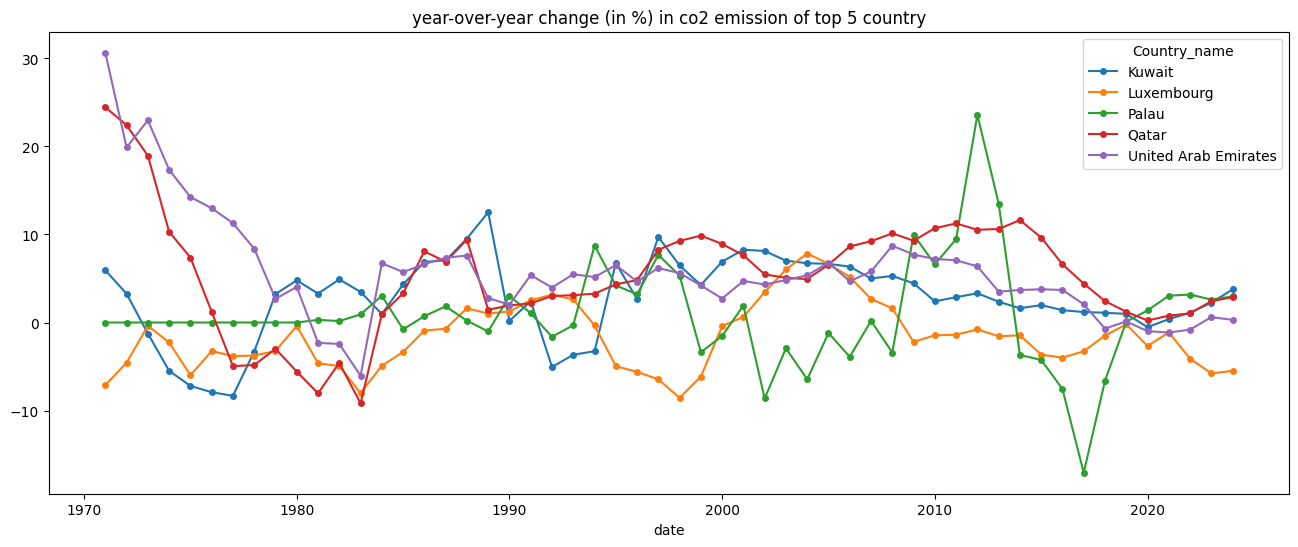

In [27]:
Top5_codes = (df.groupby('Country_code')['Co2_per_capita(in ton)']
              .mean()
              .sort_values(ascending = False)
              .index[:5]
              .to_list())
yoy_df = df[df['Country_code'].isin(Top5_codes)]
yoy_df['rolling_yoy'] = (yoy_df.groupby('Country_code')['co2_yoy_pct'].
                        transform(lambda x: x.rolling(window = 5 , min_periods=1).mean()))
p_top5 = yoy_df.pivot_table(
    index = 'date',
    columns = 'Country_name',
    values = 'rolling_yoy',
   
     
)
# print(p_top5)
plt.figure(figsize = (16,6))

ax1 = plt.subplot(1,1,1)
p_top5.plot(ax= ax1 ,  marker = 'o' ,
            title = 'year-over-year change (in %) in co2 emission of top 5 country' ,
            markersize = 4)


 


#### top 5 country on the basis of per-capita co2 emission


Text(0.5, 0, 'date')

<Figure size 640x480 with 0 Axes>

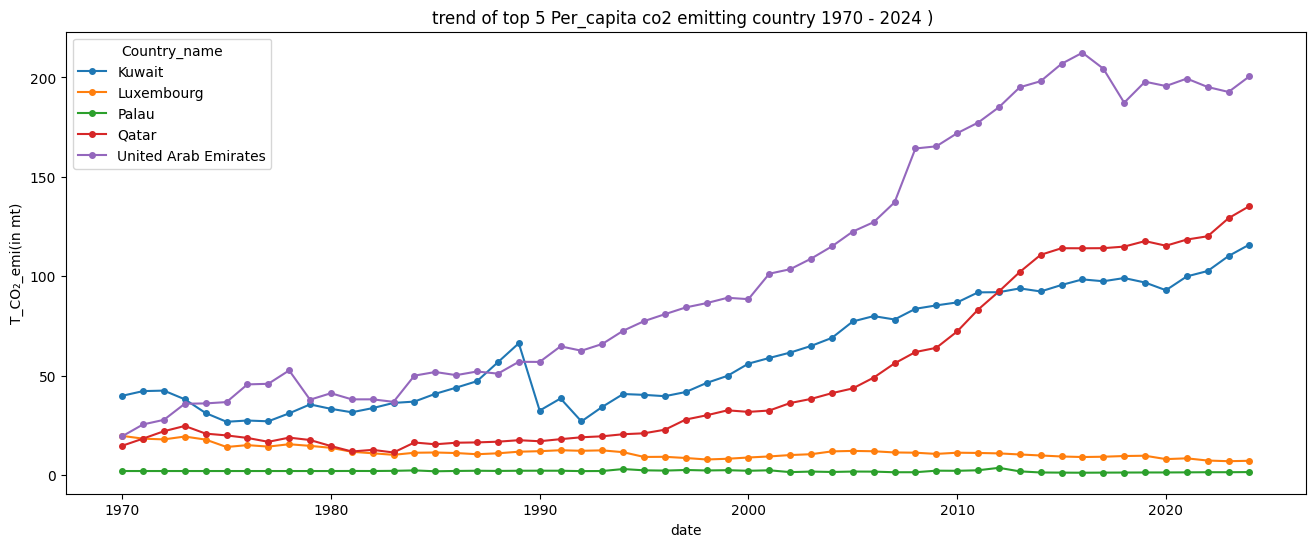

In [28]:
top5_codes_pc = (df.groupby('Country_code')['Co2_per_capita(in ton)']
              .mean()
              .sort_values(ascending = False)
              .index[:5]
              .to_list())
top5_pc_df = df[df['Country_code'].isin(top5_codes_pc)]
# top5_con = top5_df.pivot(index = 'date' , columns = 'Country_name' , values = value)
top5_pc_con = top5_pc_df.pivot_table(
    index='date',
    columns='Country_name',
    values=value,
    aggfunc='sum'    
)
top5_pc_con
plt.figure()

top5_pc_con.plot( figsize = (16,6) ,
                title = (f'trend of top 5 Per_capita co2 emitting country {top5_pc_df['date'].min() } - {top5_pc_df['date'].max() } ) ') ,
                marker = 'o' ,
                markersize=4)
plt.ylabel(value)
plt.xlabel('date')

#### Graph finding 
- on the base on per_capita emission Palau show likely flat growth while  Luxembourg show slight drop around 1982-1995 .
- United Arab Emirates sit on the top of the list and show rapid growth same for the Qatar it show spike growth around 1985 .
- Kuwait shows a drop around 1990 , but overall grow after it .


### Total vs per_capita co2 emission in latest year

In [29]:
latest = df[df['date'] == df['date'].max()]

fig = px.scatter(
    latest,
    x='Co2_per_capita(in ton)',
    y=value,
    hover_name='Country_name',
    log_x=True,
    log_y=True,
    title=(f'Total CO₂ Emissions vs CO₂ Emissions per Capita in {df['date'].max()}')
)

fig.show()

### Top 5 co2 emitting country trend  

Text(0.5, 0, 'date')

<Figure size 640x480 with 0 Axes>

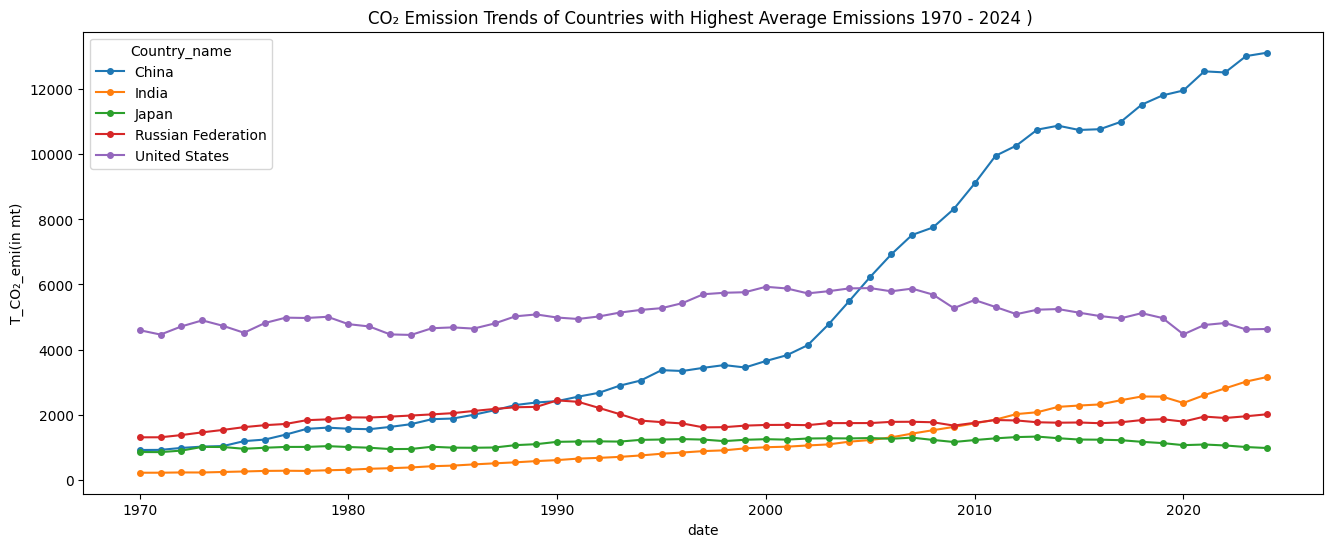

In [30]:
top5_codes = (df.groupby('Country_code')[value]
              .mean()
              .sort_values(ascending = False)
              .index[:5]
              .to_list())
top5_df = df[df['Country_code'].isin(top5_codes)]
# top5_con = top5_df.pivot(index = 'date' , columns = 'Country_name' , values = value)
top5_con = top5_df.pivot_table(
    index='date',
    columns='Country_name',
    values=value,
    aggfunc='sum'   # or 'mean', depending on your data
)


plt.figure()

top5_con.plot( figsize = (16,6) ,
                title = (f'CO₂ Emission Trends of Countries with Highest Average Emissions {top5_df['date'].min() } - {top5_df['date'].max() } ) ') ,
                marker = 'o' ,
                markersize=4)
plt.ylabel(value)
plt.xlabel('date') 

# top5_df['Country_name'].value_counts()


##### Graph (top 5 co2 emitting country) finding
- On the basis of total co2 emission' since 1970-2024 China, India, Japan, Russia and the United States have the highest average annual emissions across the study period.
- United State & Japan show a likely flatten growth in emission, while China show a spike in 2000
- India also show a moderate growth between 1980-1995 , around 1995 it show a spike growth in emission .

China shows fastest growth in co2 Emission (per_year in mt) around 1990


### top 20 country contributing in co2 emission in latest year

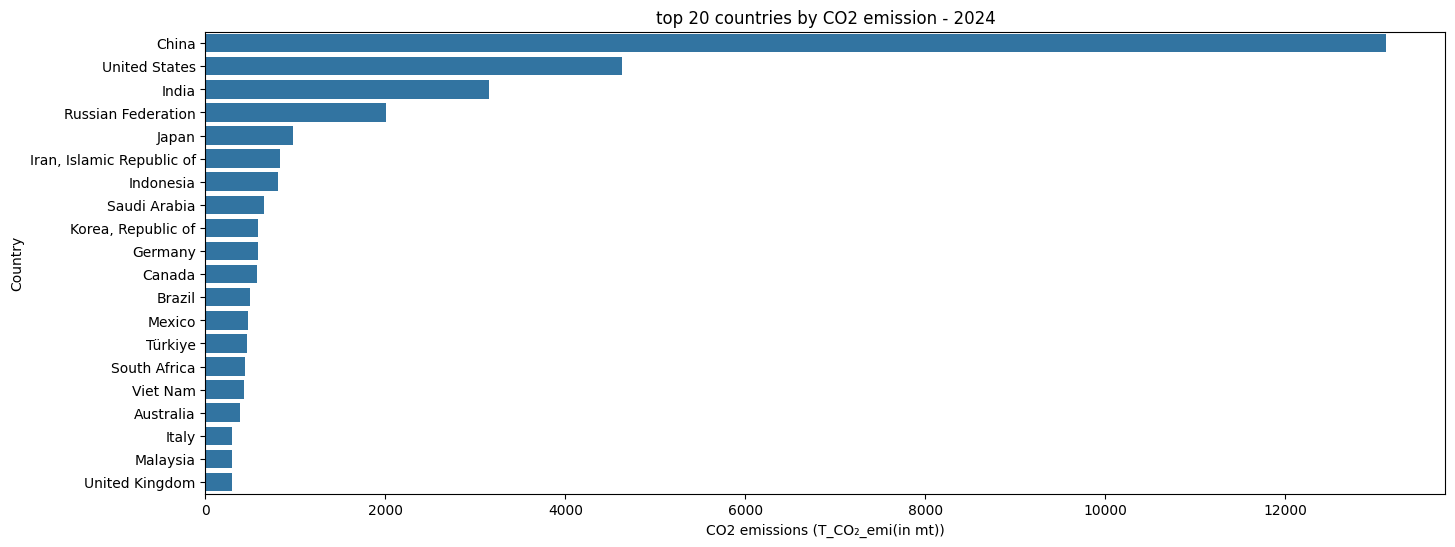

In [31]:
# ploting top 20 co2 emitting country in latest year
top_count = 20
latest_year = df.date.max()
snapshot = df[df['date']==latest_year].sort_values(value , ascending = False).head(top_count)

plt.figure(figsize = (16,6))
sns.barplot( y= 'Country_name' , x= value , data = snapshot , orient = 'h'  )
# plt.xticks(rotation = 90)
plt.title(f"top {top_count} countries by CO2 emission - {latest_year}")
plt.xlabel(f'CO2 emissions ({value})')
plt.ylabel('Country')

plt.show()
 
 


##### Graph (top 20 co2 emitting country in 2024) finding
- China is the most co2 emitting country in year 2024 on the basis of total_co2_emission .
- India comes on 3rd in this list 



In [32]:
# creating a choropleth for country wise co2 emission
fig = px.choropleth(
    snapshot,
    locations='Country_code',
    color=value,
    hover_name='Country_name',
    color_continuous_scale='turbo',
    title=f'co2 emission by country in {latest_year}',
    width=1200,
    height=700,
    template='plotly_dark'
)
fig.show()

### Exporting clean data

In [33]:
df.to_csv('../../data/processed/co2_emission_clean.csv', index=False)
df.head()


,date,T_CO₂_emi(in mt),Country_code,Co2_per_capita(in ton),Country_name,3y_rolling_mean,is_high_emitter,co2_yoy_pct,yoy_std_5yr,is_temporal_anomaly,log_co2,is_statistically_outlier
5137,1970,0.0254,ABW,0.430874,Aruba,NaN,False,NaN,NaN,False,0.025083,False
5136,1971,0.0290,ABW,0.493357,Aruba,NaN,False,14.173228,NaN,False,0.028587,False
5135,1972,0.0396,ABW,0.682206,Aruba,0.031333,False,36.551724,15.823986,False,0.038836,False
5134,1973,0.0445,ABW,0.763306,Aruba,0.037700,False,12.373737,13.469783,False,0.043538,False
5133,1974,0.0436,ABW,0.747228,Aruba,0.042567,False,-2.022472,15.932489,False,0.042676,False


## Key Findings

**1. Global trend (1970–2024):** Emissions grew gradually from 1970–1990,
then rose sharply through 1990–2010 as industrialization accelerated in
Asia. Growth has flattened since 2010, with a visible dip around 2020
(pandemic-related slowdown), though the long-term trajectory stays upward.

**2. Top contributors (latest year & historically):** China, India, Japan,
Russia, and the United States are the top 5 cumulative emitters since 1970.
China leads by a wide margin in the most recent year, with India in 3rd.

**3. Fastest growth:** China shows the sharpest acceleration, particularly
around 1990 onward. India shows a comparable growth spike around 1995
after a more moderate 1980–1995 climb.

**4. Total vs. per-capita — a different story entirely:** The top-5 lists
barely overlap. Total emissions are dominated by population size (China,
India), while per-capita emissions are led by small, energy-intensive
economies — UAE, Qatar, Kuwait, Palau, and Luxembourg — some growing
rapidly (UAE, Qatar) and others comparatively flat (Palau). This is the
clearest argument in the dataset for why dashboards need both metrics
side by side, not just total emissions.

**5. Unusual year-over-year changes:** A temporal anomaly flag
(`is_temporal_anomaly`) marks country-years where the YoY % change exceeds
both 3× that country's own 5-year rolling volatility *and* a 50% absolute
floor — catching genuine outlier jumps while ignoring small-percentage
noise in low-emission countries.

**6. Distribution shape:** Emissions are heavily right-skewed — most
countries cluster at low totals while a handful of large economies pull
the tail out. Log-transforming and applying IQR bounds identifies 18
statistical outlier rows, all belonging to China, confirming it as the
dataset's dominant high-emission case rather than a data error.

**Output:** The cleaned, feature-engineered dataset (`co2_emission_clean.csv`)
is saved to `data/processed/` and is ready for direct use in the dashboard
— no further preprocessing required.